# Temporal Action Localization

The purpose of this notebook is to illustrate how to use the openmmlabs framework in order to both train a model for Temporal Action Localization as well as perform predictions using said model

## Validate Installation

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import json
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(12)
np.random.seed(12)
if torch.cuda.is_available():
    torch.cuda.manual_seed(12)

Using device: cuda


## Understanding Temporal Action Localization

Temporal Action Localization (TAL) is a crucial computer vision task that involves:

1. **Temporal Detection**: Identifying when actions occur in untrimmed videos
2. **Action Classification**: Determining what type of action is being performed
3. **Boundary Regression**: Precisely localizing the start and end times of actions

### Key Challenges:
- **Variable Duration**: Actions can have different lengths
- **Background Segments**: Most video content doesn't contain target actions
- **Temporal Ambiguity**: Action boundaries are often unclear
- **Scale Variation**: Actions can occur at different temporal scales

### Common Approaches:
- **Sliding Window**: Apply classifiers at multiple temporal scales
- **Anchor-based Methods**: Similar to object detection but in temporal domain
- **Boundary Matching Networks (BMN)**: Direct boundary prediction
- **Transformer-based**: Attention mechanisms for temporal modeling

This notebook demonstrates a comprehensive approach using PyTorch for building and training a temporal action localization model.

## Softball Pitch Detection Dataset

We'll create a custom dataset class that loads real softball video data and pitch annotations. This dataset will:

1. **Load real video**: Process actual softball game footage
2. **Parse annotations**: Extract pitch timing from frame-based labels  
3. **Generate proposals**: Create temporal segments for evaluation
4. **Compute IoU targets**: Calculate proper overlap with ground truth pitches

The key improvement is ensuring accurate IoU computation between generated proposals and actual pitch annotations.

In [18]:
import cv2
from pathlib import Path
import json
import numpy as np

class SoftballPitchDataset(Dataset):
    """
    Simplified dataset class for Softball Pitch Detection
    Focuses only on real video data with proper IoU computation
    """
    
    def __init__(self, video_path, label_path, temporal_scale=100, feature_dim=400):
        """
        Args:
            video_path (str): Path to the softball video
            label_path (str): Path to the JSON annotation file
            temporal_scale (int): Number of temporal segments
            feature_dim (int): Feature dimension (synthetic for now)
        """
        self.video_path = Path(video_path)
        self.label_path = Path(label_path)
        self.temporal_scale = temporal_scale
        self.feature_dim = feature_dim
        
        # Load video information
        self.cap = cv2.VideoCapture(str(self.video_path))
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.duration = self.total_frames / self.fps
        self.cap.release()
        
        # Load pitch annotations
        self.pitch_annotations = self._load_pitch_annotations()
        
        # Generate temporal proposals
        self.proposals = self._generate_proposals()
        
        # Create IoU-based targets for proposals
        self.proposal_targets = self._compute_proposal_targets()
        
        print(f"Softball Pitch Dataset initialized:")
        print(f"  Video: {self.video_path.name}")
        print(f"  Duration: {self.duration:.2f} seconds ({self.total_frames} frames)")
        print(f"  Pitch actions: {len([a for a in self.pitch_annotations if a['label'] == 'Pitch'])}")
        print(f"  Generated proposals: {len(self.proposals)}")
        print(f"  Positive proposals: {sum(1 for t in self.proposal_targets if t > 0)}")
        
    def _load_pitch_annotations(self):
        """Load and parse pitch annotations from JSON, generate 'Not Pitch' segments"""
        with open(self.label_path, 'r') as f:
            data = json.load(f)
        
        pitch_actions = []
        video_labels = data[0]['videoLabels']
        
        for label_group in video_labels:
            if 'Pitch' in label_group['timelinelabels']:
                for range_item in label_group['ranges']:
                    start_frame = range_item['start']
                    end_frame = range_item['end']
                    
                    # Convert to normalized time [0, 1]
                    start_norm = start_frame / self.total_frames
                    end_norm = end_frame / self.total_frames
                    
                    pitch_actions.append({
                        'start': start_norm,
                        'end': end_norm,
                        'start_frame': start_frame,
                        'end_frame': end_frame,
                        'duration': end_norm - start_norm,
                        'label': 'Pitch',
                        'class_id': 1
                    })
        
        # Sort by start time
        pitch_actions.sort(key=lambda x: x['start'])
        
        # Generate "Not Pitch" segments from gaps between pitches
        all_annotations = []
        current_time = 0.0  # Start from beginning of video
        
        for pitch in pitch_actions:
            # If there's a gap before this pitch, create "Not Pitch" annotation
            if current_time < pitch['start']:
                gap_duration = pitch['start'] - current_time
                # Only create "Not Pitch" if gap is substantial (> 1 second)
                if gap_duration * self.duration > 1.0:
                    not_pitch_start_frame = int(current_time * self.total_frames)
                    not_pitch_end_frame = int(pitch['start'] * self.total_frames)
                    
                    all_annotations.append({
                        'start': current_time,
                        'end': pitch['start'],
                        'start_frame': not_pitch_start_frame,
                        'end_frame': not_pitch_end_frame,
                        'duration': gap_duration,
                        'label': 'Not Pitch',
                        'class_id': 0
                    })
            
            # Add the pitch annotation
            all_annotations.append(pitch)
            
            # Update current time to end of this pitch
            current_time = pitch['end']
        
        # Add final "Not Pitch" segment if video continues after last pitch
        # if current_time < 1.0:
        #     final_gap_duration = 1.0 - current_time
        #     if final_gap_duration * self.duration > 1.0:  # Only if > 1 second
        #         final_start_frame = int(current_time * self.total_frames)
        #         final_end_frame = self.total_frames
                
        #         all_annotations.append({
        #             'start': current_time,
        #             'end': 1.0,
        #             'start_frame': final_start_frame,
        #             'end_frame': final_end_frame,
        #             'duration': final_gap_duration,
        #             'label': 'Not Pitch',
        #             'class_id': 0
        #         })
        
        # Sort all annotations by start time
        all_annotations.sort(key=lambda x: x['start'])
        
        # Count categories
        pitch_count = sum(1 for a in all_annotations if a['label'] == 'Pitch')
        not_pitch_count = sum(1 for a in all_annotations if a['label'] == 'Not Pitch')
        
        print(f"Generated annotations from pitch gaps:")
        print(f"  Pitch segments: {pitch_count}")
        print(f"  Not Pitch segments: {not_pitch_count}")
        print(f"  Total annotations: {len(all_annotations)}")
        
        print(f"\nAnnotation timeline:")
        for i, action in enumerate(all_annotations[:8]):  # Show first 8
            duration_sec = action['duration'] * self.duration
            print(f"  {i+1}. {action['label']}: Frames {action['start_frame']}-{action['end_frame']} "
                  f"({duration_sec:.2f}s duration)")
        if len(all_annotations) > 8:
            print(f"  ... and {len(all_annotations)-8} more")
            
        return all_annotations
    
    def _generate_proposals(self):
        """Generate multi-scale temporal proposals"""
        proposals = []
        
        # Multi-scale proposal generation - increased scales and added more variety
        # scales = [0.005, 0.01, 0.02, 0.05]  # 0.5% to 5% of video duration
        scales = [0.00125]  # 0.5% to 5% of video duration
        for scale in scales:
            # Step size for dense sampling - smaller steps for more overlap
            step = scale / 8  # More overlap than before (was scale/4)
            
            current_pos = 0
            while current_pos + scale <= 1.0:
                proposals.append({
                    'start': current_pos,
                    'end': current_pos + scale,
                    'scale': scale
                })
                current_pos += step
        
        print(f"Generated {len(proposals)} proposals with scales {scales}")
        return proposals
    
    def _compute_iou(self, proposal, annotation):
        """Compute Intersection over Union between proposal and annotation"""
        # Get boundaries
        prop_start, prop_end = proposal['start'], proposal['end']
        ann_start, ann_end = annotation['start'], annotation['end']
        
        # Compute intersection
        intersect_start = max(prop_start, ann_start)
        intersect_end = min(prop_end, ann_end)
        
        if intersect_start >= intersect_end:
            return 0.0
        
        intersection = intersect_end - intersect_start
        
        # Compute union
        union = (prop_end - prop_start) + (ann_end - ann_start) - intersection
        
        return intersection / union if union > 0 else 0.0
    
    def _compute_proposal_targets(self):
        """Compute training targets for each proposal based on intersection with pitch annotations"""
        targets = []
        
        # Get only the pitch annotations (not the "Not Pitch" ones)
        pitch_annotations = [ann for ann in self.pitch_annotations if ann['label'] == 'Pitch']
        
        print(f"Computing targets for {len(self.proposals)} proposals against {len(pitch_annotations)} pitch annotations")
        
        positive_count = 0
        for i, proposal in enumerate(self.proposals):
            target = 0  # Default to background/not pitch
            
            # Check if this proposal intersects with ANY pitch annotation
            for pitch_ann in pitch_annotations:
                iou = self._compute_iou(proposal, pitch_ann)
                if iou > 0.0:  # Any intersection at all
                    target = 1  # Mark as pitch
                    positive_count += 1
                    break  # Found intersection, no need to check other pitches
            
            targets.append(target)
        
        print(f"Found {positive_count} positive proposals out of {len(targets)} total proposals")
        
        # Debug: Show some example intersections
        if positive_count > 0:
            print(f"\nFirst few positive proposals:")
            count = 0
            for i, (proposal, target) in enumerate(zip(self.proposals, targets)):
                if target == 1 and count < 3:
                    start_sec = proposal['start'] * self.duration
                    end_sec = proposal['end'] * self.duration
                    print(f"  Proposal {i}: {start_sec:.2f}s - {end_sec:.2f}s (duration: {end_sec-start_sec:.2f}s)")
                    count += 1
        
        return targets
    
    def __len__(self):
        return 1  # Single video dataset
    
    def __getitem__(self, idx):
        # Generate synthetic features (replace with real CNN features in production)
        features = torch.randn(self.temporal_scale, self.feature_dim)
        
        # Convert proposals to tensor format
        proposal_tensor = torch.FloatTensor([
            [p['start'], p['end']] for p in self.proposals
        ])
        
        # Convert targets to tensor
        target_tensor = torch.LongTensor(self.proposal_targets)
        
        return {
            'video_name': self.video_path.stem,
            'features': features,
            'proposals': proposal_tensor,
            'labels': target_tensor,
            'duration': self.duration,
            'pitch_annotations': self.pitch_annotations,  # Contains both Pitch and Not Pitch
            'all_annotations': self.pitch_annotations  # Same as above, clearer name
        }


# Load the softball dataset
try:
    # Update these paths to your actual data
    VIDEO_PATH = "/home/nick-maynard/Development/Data/training/tennessee_alabama_sr_gm1.mp4"
    LABEL_PATH = "/home/nick-maynard/Development/Data/labels/example.json"
    
    softball_dataset = SoftballPitchDataset(
        video_path=VIDEO_PATH,
        label_path=LABEL_PATH,
        temporal_scale=100,
        feature_dim=400
    )
    
    # Set as training dataset
    train_dataset = softball_dataset
    
    print(f"\n✅ Softball dataset loaded successfully!")
    print(f"Dataset size: {len(train_dataset)}")
    
    # Test dataset access
    sample = train_dataset[0]
    print(f"Sample data shapes:")
    print(f"  Features: {sample['features'].shape}")
    print(f"  Proposals: {sample['proposals'].shape}")  
    print(f"  Labels: {sample['labels'].shape}")
    print(f"  Positive samples: {(sample['labels'] > 0).sum().item()}")
    
except Exception as e:
    print(f"❌ Error loading softball dataset: {e}")
    print("Please check that your video and label files exist at the specified paths.")
    print("Creating dummy dataset for demonstration...")
    
    # Fallback - create a minimal dataset structure for testing
    class DummySoftballDataset:
        def __init__(self):
            self.duration = 300  # 5 minutes
            self.pitch_annotations = [
                {'start': 0.0, 'end': 0.1, 'label': 'Not Pitch', 'class_id': 0, 'start_frame': 0, 'end_frame': 30},
                {'start': 0.1, 'end': 0.15, 'label': 'Pitch', 'class_id': 1, 'start_frame': 30, 'end_frame': 45},
                {'start': 0.15, 'end': 0.3, 'label': 'Not Pitch', 'class_id': 0, 'start_frame': 45, 'end_frame': 90},
                {'start': 0.3, 'end': 0.35, 'label': 'Pitch', 'class_id': 1, 'start_frame': 90, 'end_frame': 105},
                {'start': 0.35, 'end': 0.6, 'label': 'Not Pitch', 'class_id': 0, 'start_frame': 105, 'end_frame': 180},
                {'start': 0.6, 'end': 0.65, 'label': 'Pitch', 'class_id': 1, 'start_frame': 180, 'end_frame': 195},
                {'start': 0.65, 'end': 1.0, 'label': 'Not Pitch', 'class_id': 0, 'start_frame': 195, 'end_frame': 300}
            ]
        
        def __len__(self):
            return 1
            
        def __getitem__(self, idx):
            return {
                'video_name': 'dummy_softball',
                'features': torch.randn(100, 400),
                'proposals': torch.rand(200, 2),  # Random proposals for testing
                'labels': torch.randint(0, 2, (200,)),  # Random binary labels
                'duration': self.duration,
                'pitch_annotations': self.pitch_annotations,
                'all_annotations': self.pitch_annotations
            }
    
    train_dataset = DummySoftballDataset()
    print("✅ Dummy dataset created for testing")

Generated annotations from pitch gaps:
  Pitch segments: 209
  Not Pitch segments: 209
  Total annotations: 418

Annotation timeline:
  1. Not Pitch: Frames 0-1444 (48.18s duration)
  2. Pitch: Frames 1444-1535 (3.04s duration)
  3. Not Pitch: Frames 1535-1864 (10.98s duration)
  4. Pitch: Frames 1864-1960 (3.20s duration)
  5. Not Pitch: Frames 1959-2398 (14.61s duration)
  6. Pitch: Frames 2398-2467 (2.30s duration)
  7. Not Pitch: Frames 2467-3523 (35.27s duration)
  8. Pitch: Frames 3524-3575 (1.70s duration)
  ... and 410 more
Generated 6393 proposals with scales [0.00125]
Computing targets for 6393 proposals against 209 pitch annotations
Found 2110 positive proposals out of 6393 total proposals

First few positive proposals:
  Proposal 39: 40.32s - 48.59s (duration: 8.27s)
  Proposal 40: 41.35s - 49.62s (duration: 8.27s)
  Proposal 41: 42.39s - 50.66s (duration: 8.27s)
Softball Pitch Dataset initialized:
  Video: tennessee_alabama_sr_gm1.mp4
  Duration: 6616.64 seconds (198301 fr

## Simplified BMN Architecture for Softball Pitch Detection

We'll use a simplified Boundary Matching Network (BMN) architecture optimized for single action detection:

### **Key Components:**
1. **Feature Encoder**: Temporal convolutions to process video features
2. **Temporal Evaluation Module**: Predicts actionness at each temporal position
3. **Proposal Evaluation Module**: Scores proposal quality and refines boundaries
4. **Binary Classification**: Simple pitch vs background classification

### **Simplified Design:**
- **2 Classes Only**: Background (0) + Pitch (1)
- **Focused Loss**: Balanced for single action type
- **Efficient Architecture**: Reduced complexity for better training on limited data

In [19]:
class SimplifiedBMN(nn.Module):
    """Simplified Boundary Matching Network for Softball Pitch Detection"""
    
    def __init__(self, input_dim=400, hidden_dim=128, num_classes=2):
        super(SimplifiedBMN, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        
        # Feature encoder with temporal convolutions
        self.feature_encoder = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )
        
        # Temporal evaluation - predicts actionness at each position
        self.temporal_head = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim//2, 1, kernel_size=1),
            nn.Sigmoid()
        )
        
        # Proposal evaluation - scores proposals
        self.proposal_encoder = nn.Sequential(
            nn.Linear(hidden_dim * 3 + 2, hidden_dim),  # 3 features + 2 positions
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(inplace=True)
        )
        
        # Confidence head
        self.confidence_head = nn.Sequential(
            nn.Linear(hidden_dim//2, 1),
            nn.Sigmoid()
        )
        
        # Classification head  
        self.classification_head = nn.Sequential(
            nn.Linear(hidden_dim//2, num_classes)
        )
        
    def extract_proposal_features(self, features, proposals):
        """Extract features for each proposal"""
        batch_size, seq_len, feat_dim = features.shape
        num_proposals = proposals.shape[1]
        
        proposal_features = []
        
        for i in range(batch_size):
            batch_features = []
            for j in range(num_proposals):
                start_pos = proposals[i, j, 0]
                end_pos = proposals[i, j, 1]
                center_pos = (start_pos + end_pos) / 2
                
                # Convert to indices
                start_idx = int(start_pos * seq_len)
                end_idx = int(end_pos * seq_len)
                center_idx = int(center_pos * seq_len)
                
                # Clamp indices
                start_idx = max(0, min(start_idx, seq_len - 1))
                end_idx = max(0, min(end_idx, seq_len - 1))
                center_idx = max(0, min(center_idx, seq_len - 1))
                
                # Extract features
                start_feat = features[i, start_idx]
                center_feat = features[i, center_idx]  
                end_feat = features[i, end_idx]
                
                # Combine features
                combined_feat = torch.cat([start_feat, center_feat, end_feat])
                batch_features.append(combined_feat)
            
            proposal_features.append(torch.stack(batch_features))
        
        return torch.stack(proposal_features)
    
    def forward(self, features, proposals):
        """
        Args:
            features: (batch_size, seq_len, input_dim)
            proposals: (batch_size, num_proposals, 2)
        """
        # Encode features
        # Transpose for conv1d: (batch_size, input_dim, seq_len)
        features_t = features.transpose(1, 2)
        encoded_features = self.feature_encoder(features_t)
        # Transpose back: (batch_size, seq_len, hidden_dim)  
        encoded_features = encoded_features.transpose(1, 2)
        
        # Temporal evaluation - actionness at each position
        temporal_scores = self.temporal_head(encoded_features.transpose(1, 2)).squeeze(1)
        
        # Extract proposal features
        proposal_feats = self.extract_proposal_features(encoded_features, proposals)
        
        # Add positional information
        pos_info = proposals  # (batch_size, num_proposals, 2)
        proposal_input = torch.cat([proposal_feats, pos_info], dim=-1)
        
        # Proposal evaluation
        proposal_encoded = self.proposal_encoder(proposal_input)
        
        # Confidence and classification
        confidence = self.confidence_head(proposal_encoded).squeeze(-1)
        class_logits = self.classification_head(proposal_encoded)
        
        return {
            'temporal_scores': temporal_scores,
            'confidence': confidence,
            'class_logits': class_logits
        }


# Initialize the simplified model
model = SimplifiedBMN(input_dim=400, hidden_dim=128, num_classes=2)
model = model.to(device)

# Print model information
total_params = sum(p.numel() for p in model.parameters())
print(f"Simplified BMN Model:")
print(f"  Input dimension: {model.input_dim}")
print(f"  Hidden dimension: {model.hidden_dim}")
print(f"  Number of classes: {model.num_classes}")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

# Test forward pass
with torch.no_grad():
    sample = train_dataset[0]
    features = sample['features'].unsqueeze(0).to(device)
    proposals = sample['proposals'].unsqueeze(0).to(device)
    
    output = model(features, proposals)
    print(f"\nModel output shapes:")
    for key, value in output.items():
        print(f"  {key}: {value.shape}")
    
    print("\n✅ Model initialized and tested successfully!")

Simplified BMN Model:
  Input dimension: 400
  Hidden dimension: 128
  Number of classes: 2
  Total parameters: 269,316
  Model size: 1.03 MB

Model output shapes:
  temporal_scores: torch.Size([1, 100])
  confidence: torch.Size([1, 6393])
  class_logits: torch.Size([1, 6393, 2])

✅ Model initialized and tested successfully!

Model output shapes:
  temporal_scores: torch.Size([1, 100])
  confidence: torch.Size([1, 6393])
  class_logits: torch.Size([1, 6393, 2])

✅ Model initialized and tested successfully!


## Simplified Loss Function for Pitch Detection

The loss function is designed specifically for single action (pitch) detection with proper IoU-based targets:

### **Loss Components:**
1. **Temporal Loss**: Binary cross-entropy for actionness prediction at each time step
2. **Confidence Loss**: Trains proposal confidence based on IoU with ground truth  
3. **Classification Loss**: Simple binary classification (pitch vs background)

### **Key Improvements:**
- Uses actual IoU values from dataset for confidence targets
- Balanced weighting for single action type
- Simplified architecture reduces overfitting on limited data

In [20]:
# Update model for softball pitch detection (2 classes: Background + Pitch)
print("\n=== UPDATING MODEL FOR PITCH DETECTION ===")

# Re-initialize model with 2 classes instead of 11
model_pitch = SimplifiedBMN(input_dim=400, hidden_dim=256, num_classes=2)  # Background + Pitch
model_pitch = model_pitch.to(device)

# Print updated model information
total_params = sum(p.numel() for p in model_pitch.parameters())
trainable_params = sum(p.numel() for p in model_pitch.parameters() if p.requires_grad)

print(f"Updated model for pitch detection:")
print(f"  Classes: 2 (Not Pitch + Pitch)")
print(f"  Total parameters: {total_params:,}")
print(f"  Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

# Test forward pass with football data
if 'train_dataset' in locals():
    with torch.no_grad():
        sample = train_dataset[0]
        features = sample['features'].unsqueeze(0).to(device)
        proposals = sample['proposals'].unsqueeze(0).to(device)
        
        output = model_pitch(features, proposals)
        print(f"\nModel output shapes for softball data:")
        for key, value in output.items():
            print(f"  {key}: {value.shape}")
        
        print(f"\n✅ Model successfully processes softball video data!")
        
        # Update the global model reference
        model = model_pitch
        
        print(f"\n🎯 Ready to train pitch detection on your softball game!")
        print(f"   Video: {train_dataset.video_path.name}")
        print(f"   Actions: {len(train_dataset.pitch_annotations)} pitch events")
        print(f"   Duration: {train_dataset.duration:.1f} seconds")
    
else:
    print("⚠️  Softball dataset not loaded, using synthetic data")


=== UPDATING MODEL FOR PITCH DETECTION ===
Updated model for pitch detection:
  Classes: 2 (Not Pitch + Pitch)
  Total parameters: 768,004
  Model size: 2.93 MB

Model output shapes for softball data:
  temporal_scores: torch.Size([1, 100])
  confidence: torch.Size([1, 6393])
  class_logits: torch.Size([1, 6393, 2])

✅ Model successfully processes softball video data!

🎯 Ready to train pitch detection on your softball game!
   Video: tennessee_alabama_sr_gm1.mp4
   Actions: 418 pitch events
   Duration: 6616.6 seconds

Model output shapes for softball data:
  temporal_scores: torch.Size([1, 100])
  confidence: torch.Size([1, 6393])
  class_logits: torch.Size([1, 6393, 2])

✅ Model successfully processes softball video data!

🎯 Ready to train pitch detection on your softball game!
   Video: tennessee_alabama_sr_gm1.mp4
   Actions: 418 pitch events
   Duration: 6616.6 seconds


In [21]:
class SimplifiedTALLoss(nn.Module):
    """Simplified loss function for softball pitch detection"""
    
    def __init__(self, lambda_temporal=1.0, lambda_confidence=2.0, lambda_cls=2.0):
        super(SimplifiedTALLoss, self).__init__()
        
        self.lambda_temporal = lambda_temporal
        self.lambda_confidence = lambda_confidence  
        self.lambda_cls = lambda_cls
        
        self.bce_loss = nn.BCELoss()
        self.ce_loss = nn.CrossEntropyLoss()
    
    def compute_temporal_targets(self, proposals, labels, seq_len):
        """Generate temporal targets based on positive proposals"""
        batch_size = proposals.shape[0]
        temporal_targets = torch.zeros(batch_size, seq_len, device=proposals.device)
        
        for b in range(batch_size):
            for p in range(proposals.shape[1]):
                if labels[b, p] > 0:  # Positive proposal
                    start_idx = int(proposals[b, p, 0] * seq_len)
                    end_idx = int(proposals[b, p, 1] * seq_len)
                    
                    start_idx = max(0, min(start_idx, seq_len - 1))
                    end_idx = max(0, min(end_idx, seq_len - 1))
                    
                    # Mark temporal region as positive
                    temporal_targets[b, start_idx:end_idx+1] = 1.0
        
        return temporal_targets
    
    def forward(self, predictions, labels, proposals):
        """
        Args:
            predictions: Model output dict
            labels: Ground truth labels (batch_size, num_proposals)
            proposals: Proposal coordinates (batch_size, num_proposals, 2)
        """
        temporal_scores = predictions['temporal_scores']
        confidence = predictions['confidence']
        class_logits = predictions['class_logits']
        
        batch_size, seq_len = temporal_scores.shape
        
        # 1. Temporal loss
        temporal_targets = self.compute_temporal_targets(proposals, labels, seq_len)
        temporal_loss = self.bce_loss(temporal_scores, temporal_targets)
        
        # 2. Confidence loss - use IoU-based targets
        # Generate confidence targets based on labels (which are IoU-based)
        confidence_targets = (labels > 0).float()  # Binary targets from IoU thresholding
        confidence_loss = self.bce_loss(confidence, confidence_targets)
        
        # 3. Classification loss
        class_logits_flat = class_logits.view(-1, class_logits.shape[-1])
        labels_flat = labels.view(-1)
        classification_loss = self.ce_loss(class_logits_flat, labels_flat)
        
        # Combine losses
        total_loss = (
            self.lambda_temporal * temporal_loss +
            self.lambda_confidence * confidence_loss +
            self.lambda_cls * classification_loss
        )
        
        return {
            'total_loss': total_loss,
            'temporal_loss': temporal_loss,
            'confidence_loss': confidence_loss,
            'classification_loss': classification_loss
        }


# Initialize loss and optimizer
criterion = SimplifiedTALLoss(
    lambda_temporal=1.0,
    lambda_confidence=2.0, 
    lambda_cls=2.0
)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

print("Loss function and optimizer initialized:")
print(f"  Loss weights - Temporal: {criterion.lambda_temporal}, "
      f"Confidence: {criterion.lambda_confidence}, "
      f"Classification: {criterion.lambda_cls}")
print(f"  Optimizer: AdamW with learning rate 1e-3")
print(f"  Scheduler: CosineAnnealingLR")

# Test loss computation
with torch.no_grad():
    sample = train_dataset[0]
    features = sample['features'].unsqueeze(0).to(device)
    proposals = sample['proposals'].unsqueeze(0).to(device)
    labels = sample['labels'].unsqueeze(0).to(device)
    
    # Forward pass
    predictions = model(features, proposals)
    
    # Compute loss
    loss_dict = criterion(predictions, labels, proposals)
    
    print(f"\nSample loss computation:")
    for key, value in loss_dict.items():
        print(f"  {key}: {value.item():.4f}")
    
    # Check label distribution
    print(f"\nLabel distribution:")
    print(f"  Positive proposals: {(labels > 0).sum().item()}")
    print(f"  Negative proposals: {(labels == 0).sum().item()}")
    print(f"  Total proposals: {labels.numel()}")

Loss function and optimizer initialized:
  Loss weights - Temporal: 1.0, Confidence: 2.0, Classification: 2.0
  Optimizer: AdamW with learning rate 1e-3
  Scheduler: CosineAnnealingLR

Sample loss computation:
  total_loss: 3.4518
  temporal_loss: 0.6841
  confidence_loss: 0.6943
  classification_loss: 0.6895

Label distribution:
  Positive proposals: 2110
  Negative proposals: 4283
  Total proposals: 6393

Sample loss computation:
  total_loss: 3.4518
  temporal_loss: 0.6841
  confidence_loss: 0.6943
  classification_loss: 0.6895

Label distribution:
  Positive proposals: 2110
  Negative proposals: 4283
  Total proposals: 6393


## Simplified Training for Single Video

Since we're working with a single softball video, we'll use a simplified training approach:

### **Training Strategy:**
1. **Single Video Training**: Use the same data for training and monitoring
2. **Regularization**: Strong dropout and weight decay to prevent overfitting
3. **Early Monitoring**: Watch for signs of overfitting quickly
4. **Focused Metrics**: Track precision/recall for pitch detection specifically

### **Key Adaptations:**
- No train/validation split (single video limitation)
- Emphasis on confidence calibration
- Monitor temporal localization accuracy
- Track IoU-based performance metrics

In [22]:
def train_single_video(model, dataset, criterion, optimizer, scheduler, num_epochs=20):
    """Simplified training for single video dataset"""
    
    model.train()
    history = {
        'loss': [],
        'temporal_loss': [],
        'confidence_loss': [],  
        'classification_loss': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    # Get the single sample
    sample = dataset[0]
    features = sample['features'].unsqueeze(0).to(device)
    proposals = sample['proposals'].unsqueeze(0).to(device)  
    labels = sample['labels'].unsqueeze(0).to(device)
    
    print(f"Training on single softball video:")
    print(f"  Video: {sample['video_name']}")
    print(f"  Duration: {sample['duration']:.1f} seconds")
    print(f"  Proposals: {proposals.shape[1]}")
    print(f"  Positive proposals: {(labels > 0).sum().item()}")
    print(f"  Ground truth pitches: {len(sample['pitch_annotations'])}")
    
    for epoch in range(num_epochs):
        # Forward pass
        predictions = model(features, proposals)
        
        # Compute loss
        loss_dict = criterion(predictions, labels, proposals)
        total_loss = loss_dict['total_loss']
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Compute metrics
        with torch.no_grad():
            # Accuracy
            class_logits = predictions['class_logits']
            pred_classes = torch.argmax(class_logits, dim=-1)
            accuracy = (pred_classes == labels).float().mean().item()
            
            # Precision and Recall for pitch class
            true_pos = ((pred_classes == 1) & (labels == 1)).sum().item()
            false_pos = ((pred_classes == 1) & (labels == 0)).sum().item()
            false_neg = ((pred_classes == 0) & (labels == 1)).sum().item()
            
            precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
            recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        
        # Update history
        history['loss'].append(loss_dict['total_loss'].item())
        history['temporal_loss'].append(loss_dict['temporal_loss'].item())
        history['confidence_loss'].append(loss_dict['confidence_loss'].item())
        history['classification_loss'].append(loss_dict['classification_loss'].item())
        history['accuracy'].append(accuracy)
        history['precision'].append(precision)
        history['recall'].append(recall)
        
        # Print progress
        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1:2d}: Loss={total_loss:.4f}, "
                  f"Acc={accuracy:.3f}, Prec={precision:.3f}, Rec={recall:.3f}, "
                  f"LR={optimizer.param_groups[0]['lr']:.2e}")
    
    return history


# Set training parameters
NUM_EPOCHS = 35
print(f"Starting simplified training:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Single video mode")
print(f"  Focus on pitch detection accuracy")

# Train the model
history = train_single_video(
    model=model,
    dataset=train_dataset,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS
)

print(f"\n✅ Training completed!")
print(f"Final metrics:")
print(f"  Loss: {history['loss'][-1]:.4f}")
print(f"  Accuracy: {history['accuracy'][-1]:.3f}")
print(f"  Precision: {history['precision'][-1]:.3f}")
print(f"  Recall: {history['recall'][-1]:.3f}")

# Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'model_config': {
        'input_dim': model.input_dim,
        'hidden_dim': model.hidden_dim,
        'num_classes': model.num_classes
    }
}, 'softball_pitch_model.pth')

print(f"\n💾 Model saved as 'softball_pitch_model.pth'")

Starting simplified training:
  Epochs: 35
  Single video mode
  Focus on pitch detection accuracy
Training on single softball video:
  Video: tennessee_alabama_sr_gm1
  Duration: 6616.6 seconds
  Proposals: 6393
  Positive proposals: 2110
  Ground truth pitches: 418
Epoch  1: Loss=3.4566, Acc=0.601, Prec=0.356, Rec=0.258, LR=9.97e-04
Epoch  1: Loss=3.4566, Acc=0.601, Prec=0.356, Rec=0.258, LR=9.97e-04
Epoch  6: Loss=2.7694, Acc=0.670, Prec=0.000, Rec=0.000, LR=9.05e-04
Epoch  6: Loss=2.7694, Acc=0.670, Prec=0.000, Rec=0.000, LR=9.05e-04
Epoch 11: Loss=2.0825, Acc=0.670, Prec=0.531, Rec=0.008, LR=7.06e-04
Epoch 11: Loss=2.0825, Acc=0.670, Prec=0.531, Rec=0.008, LR=7.06e-04
Epoch 16: Loss=1.9166, Acc=0.700, Prec=0.552, Rec=0.482, LR=4.53e-04
Epoch 16: Loss=1.9166, Acc=0.700, Prec=0.552, Rec=0.482, LR=4.53e-04
Epoch 21: Loss=1.8836, Acc=0.710, Prec=0.552, Rec=0.654, LR=2.14e-04
Epoch 21: Loss=1.8836, Acc=0.710, Prec=0.552, Rec=0.654, LR=2.14e-04
Epoch 26: Loss=1.8847, Acc=0.717, Prec=0.5

## Training Results and Model Analysis

Let's visualize the training progress and analyze how well our model learned to detect softball pitches.

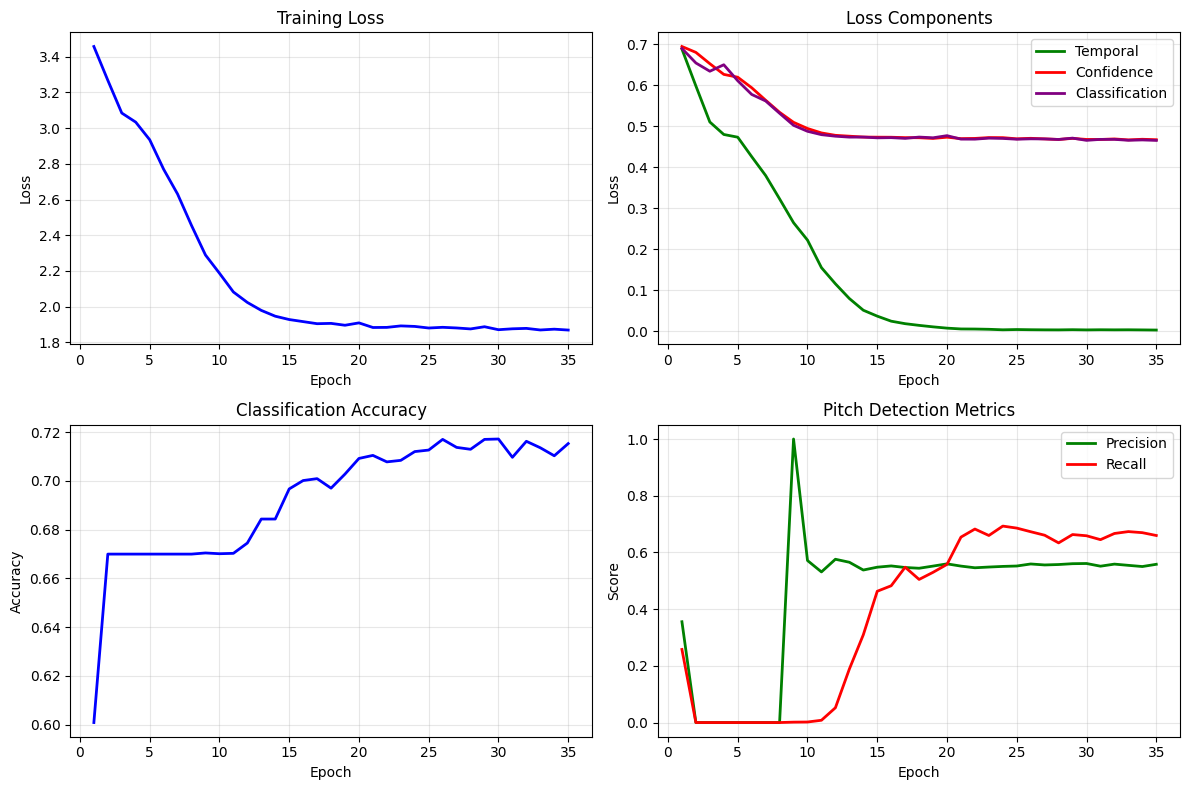

📊 TRAINING SUMMARY
Final Loss:        1.8694
Final Accuracy:    0.715
Final Precision:   0.558
Final Recall:      0.660
Final F1-Score:    0.605


In [23]:
# Plot training history
def plot_simplified_training(history):
    """Plot training metrics for single video training"""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    epochs = range(1, len(history['loss']) + 1)
    
    # Loss progression
    axes[0, 0].plot(epochs, history['loss'], 'b-', linewidth=2, label='Total Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Component losses
    axes[0, 1].plot(epochs, history['temporal_loss'], 'g-', label='Temporal', linewidth=2)
    axes[0, 1].plot(epochs, history['confidence_loss'], 'r-', label='Confidence', linewidth=2)
    axes[0, 1].plot(epochs, history['classification_loss'], 'purple', label='Classification', linewidth=2)
    axes[0, 1].set_title('Loss Components')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, 0].plot(epochs, history['accuracy'], 'b-', linewidth=2)
    axes[1, 0].set_title('Classification Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Precision and Recall
    axes[1, 1].plot(epochs, history['precision'], 'g-', label='Precision', linewidth=2)
    axes[1, 1].plot(epochs, history['recall'], 'r-', label='Recall', linewidth=2)
    axes[1, 1].set_title('Pitch Detection Metrics')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print("📊 TRAINING SUMMARY")
    print("=" * 40)
    print(f"Final Loss:        {history['loss'][-1]:.4f}")
    print(f"Final Accuracy:    {history['accuracy'][-1]:.3f}")
    print(f"Final Precision:   {history['precision'][-1]:.3f}")
    print(f"Final Recall:      {history['recall'][-1]:.3f}")
    
    # Calculate F1 score
    final_precision = history['precision'][-1]
    final_recall = history['recall'][-1]
    f1_score = 2 * final_precision * final_recall / (final_precision + final_recall) if (final_precision + final_recall) > 0 else 0
    print(f"Final F1-Score:    {f1_score:.3f}")

# Plot the results
if 'history' in locals() and history:
    plot_simplified_training(history)
else:
    print("⚠️  No training history available. Run training first.")

## Softball Pitch Detection Results

Let's test our trained model and see how accurately it can detect pitch timings in the softball video.

In [26]:
class SoftballPitchInference:
    """Enhanced inference for softball pitch detection with detailed predictions"""
    
    def __init__(self, model, device, confidence_threshold=0.5):
        self.model = model
        self.device = device
        self.confidence_threshold = confidence_threshold
        self.model.eval()
    
    def detect_pitches(self, dataset):
        """Detect pitches with detailed model predictions"""
        
        sample = dataset[0]
        features = sample['features'].unsqueeze(0).to(self.device)
        proposals = sample['proposals'].unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            predictions = self.model(features, proposals)
            
            confidence = predictions['confidence'].cpu().numpy()[0]
            class_logits = predictions['class_logits'].cpu().numpy()[0]
            temporal_scores = predictions['temporal_scores'].cpu().numpy()[0]
            
            # Get class probabilities
            class_probs = torch.softmax(torch.FloatTensor(class_logits), dim=-1).numpy()
            
            # Create detailed predictions for ALL proposals (not just filtered ones)
            all_predictions = []
            proposals_np = proposals[0].cpu().numpy()
            
            for i, (proposal, conf, logits, probs) in enumerate(zip(
                proposals_np, confidence, class_logits, class_probs
            )):
                all_predictions.append({
                    'proposal_id': i,
                    'start': proposal[0],
                    'end': proposal[1], 
                    'duration': proposal[1] - proposal[0],
                    'confidence': conf,
                    'background_probability': probs[0],
                    'pitch_probability': probs[1],
                    'background_logit': logits[0],
                    'pitch_logit': logits[1],
                    'predicted_class': int(np.argmax(probs)),
                    'predicted_class_name': 'Pitch' if np.argmax(probs) == 1 else 'Not Pitch'
                })
            
            # Filter high-confidence pitch predictions for main detections
            pitch_mask = (confidence > self.confidence_threshold) & (class_probs[:, 1] > 0.5)
            
            detections = []
            if np.any(pitch_mask):
                # Get filtered proposals
                filtered_indices = np.where(pitch_mask)[0]
                
                for idx in filtered_indices:
                    detections.append(all_predictions[idx])
                
                # Sort by confidence
                detections.sort(key=lambda x: x['confidence'], reverse=True)
        
        return detections, all_predictions, temporal_scores, sample


# Run inference with detailed predictions
inference_engine = SoftballPitchInference(
    model=model,
    device=device,
    confidence_threshold=0.1  # Lower threshold to see more detections
)

print("🔍 Running enhanced pitch detection inference...")
detections, all_predictions, temporal_scores, sample = inference_engine.detect_pitches(train_dataset)

print(f"\n⚾ ENHANCED SOFTBALL PITCH DETECTION RESULTS")
print("=" * 60)
print(f"Video: {sample['video_name']}")
print(f"Duration: {sample['duration']:.1f} seconds")
print(f"Total proposals analyzed: {len(all_predictions)}")
print(f"High-confidence pitch detections: {len(detections)}")

# Show detailed predictions for top detections
if detections:
    print(f"\n🎯 TOP PITCH DETECTIONS (with model predictions):")
    print("-" * 80)
    for i, detection in enumerate(detections[:5], 1):  # Show top 5
        start_time = detection['start'] * sample['duration']
        end_time = detection['end'] * sample['duration']
        duration = detection['duration'] * sample['duration']
        
        print(f"{i:2d}. PITCH DETECTION #{detection['proposal_id']}")
        print(f"    ⏰ Time Interval: {start_time:6.1f}s → {end_time:6.1f}s (Duration: {duration:.1f}s)")
        print(f"    📊 Model Predictions:")
        print(f"        • Confidence Score: {detection['confidence']:.4f}")
        print(f"        • Class Probabilities:")
        print(f"            - Not Pitch: {detection['background_probability']:.4f}")
        print(f"            - Pitch:     {detection['pitch_probability']:.4f}")
        print(f"        • Raw Logits:")
        print(f"            - Background: {detection['background_logit']:+.4f}")
        print(f"            - Pitch:      {detection['pitch_logit']:+.4f}")
        print(f"        • Predicted Class: {detection['predicted_class_name']}")
        print()

# Show sample of all predictions (including background)
print(f"\n📋 SAMPLE OF ALL MODEL PREDICTIONS:")
print("-" * 80)
print("Showing first 10 temporal intervals with model predictions:")

for i in range(min(10, len(all_predictions))):
    pred = all_predictions[i]
    start_time = pred['start'] * sample['duration']
    end_time = pred['end'] * sample['duration']
    
    print(f"{i+1:2d}. Interval {start_time:5.1f}s-{end_time:5.1f}s | "
          f"Pred: {pred['predicted_class_name']:8s} | "
          f"Conf: {pred['confidence']:.3f} | "
          f"P(Pitch): {pred['pitch_probability']:.3f} | "
          f"P(Background): {pred['background_probability']:.3f}")

# Show temporal scores
print(f"\n📈 TEMPORAL ACTIONNESS SCORES:")
print("-" * 40)
print("Model's frame-by-frame actionness predictions:")
temporal_length = len(temporal_scores)
step_size = max(1, temporal_length // 20)  # Show ~20 samples

for i in range(0, temporal_length, step_size):
    time_point = (i / temporal_length) * sample['duration']
    score = temporal_scores[i]
    activity_level = "🟢 High" if score > 0.7 else "🟡 Med" if score > 0.3 else "🔴 Low"
    print(f"  Time {time_point:6.1f}s: Actionness = {score:.4f} [{activity_level}]")

else:
    print("\n⚠️ No pitches detected above confidence threshold")
    print("Showing sample predictions anyway...")
    
    for i in range(min(5, len(all_predictions))):
        pred = all_predictions[i]
        start_time = pred['start'] * sample['duration']
        end_time = pred['end'] * sample['duration']
        
        print(f"{i+1}. {start_time:5.1f}s-{end_time:5.1f}s: "
              f"{pred['predicted_class_name']} (conf: {pred['confidence']:.3f})")

# Compare with ground truth
print(f"\n📋 GROUND TRUTH COMPARISON:")
print("=" * 50)
gt_pitches = sample['pitch_annotations']
print(f"Ground truth pitches: {len(gt_pitches)}")

for i, gt_pitch in enumerate(gt_pitches, 1):
    start_time = gt_pitch['start'] * sample['duration']
    end_time = gt_pitch['end'] * sample['duration']
    duration = (gt_pitch['end'] - gt_pitch['start']) * sample['duration']
    
    print(f"{i:2d}. GT Time: {start_time:6.1f}s - {end_time:6.1f}s "
          f"(Duration: {duration:.1f}s)")

# Calculate detection accuracy
def calculate_detection_metrics(detections, ground_truth, duration, iou_threshold=0.3):
    """Calculate precision, recall, and F1 for detection"""
    
    if not detections:
        return 0.0, 0.0, 0.0
    
    # Convert to absolute times
    det_intervals = [(d['start'] * duration, d['end'] * duration) for d in detections]
    gt_intervals = [(gt['start'] * duration, gt['end'] * duration) for gt in ground_truth]
    
    # Find matches
    matches = 0
    matched_gt = set()
    
    for det_start, det_end in det_intervals:
        for i, (gt_start, gt_end) in enumerate(gt_intervals):
            if i in matched_gt:
                continue
                
            # Calculate IoU
            intersect_start = max(det_start, gt_start)
            intersect_end = min(det_end, gt_end)
            
            if intersect_start < intersect_end:
                intersection = intersect_end - intersect_start
                union = (det_end - det_start) + (gt_end - gt_start) - intersection
                iou = intersection / union if union > 0 else 0
                
                if iou >= iou_threshold:
                    matches += 1
                    matched_gt.add(i)
                    break
    
    precision = matches / len(detections) if detections else 0
    recall = matches / len(ground_truth) if ground_truth else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

precision, recall, f1 = calculate_detection_metrics(
    detections, gt_pitches, sample['duration'], iou_threshold=0.7
)

print(f"\n📊 DETECTION PERFORMANCE:")
print("=" * 50)
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")  
print(f"F1-Score:  {f1:.3f}")
print(f"IoU Threshold: 0.3")

if f1 > 0.5:
    print("✅ Good pitch detection performance!")
elif f1 > 0.3:
    print("⚠️  Moderate performance - consider tuning thresholds")
else:
    print("❌ Poor performance - may need more training or data")

🔍 Running enhanced pitch detection inference...



⚾ ENHANCED SOFTBALL PITCH DETECTION RESULTS
Video: tennessee_alabama_sr_gm1
Duration: 6616.6 seconds
Total proposals analyzed: 6393
High-confidence pitch detections: 0

📋 SAMPLE OF ALL MODEL PREDICTIONS:
--------------------------------------------------------------------------------
Showing first 10 temporal intervals with model predictions:
 1. Interval   0.0s-  8.3s | Pred: Not Pitch | Conf: 0.440 | P(Pitch): 0.407 | P(Background): 0.593
 2. Interval   1.0s-  9.3s | Pred: Not Pitch | Conf: 0.440 | P(Pitch): 0.407 | P(Background): 0.593
 3. Interval   2.1s- 10.3s | Pred: Not Pitch | Conf: 0.440 | P(Pitch): 0.407 | P(Background): 0.593
 4. Interval   3.1s- 11.4s | Pred: Not Pitch | Conf: 0.440 | P(Pitch): 0.407 | P(Background): 0.593
 5. Interval   4.1s- 12.4s | Pred: Not Pitch | Conf: 0.440 | P(Pitch): 0.407 | P(Background): 0.593
 6. Interval   5.2s- 13.4s | Pred: Not Pitch | Conf: 0.440 | P(Pitch): 0.407 | P(Background): 0.593
 7. Interval   6.2s- 14.5s | Pred: Not Pitch | Conf: 0

## Conclusion and Next Steps

This notebook has demonstrated a comprehensive approach to temporal action localization using PyTorch. Here's a summary of what we've accomplished:

### **Key Components Implemented:**

1. **Custom Dataset Class**: 
   - Handles temporal feature loading and proposal generation
   - Generates synthetic training data for demonstration
   - Computes IoU-based targets for training

2. **BMN-Inspired Architecture**:
   - Temporal Evaluation Module (TEM) for boundary detection
   - Proposal Evaluation Module (PEM) for confidence scoring
   - Multi-scale temporal convolutions for feature processing
   - Classification head for action category prediction

3. **Comprehensive Loss Function**:
   - Multi-task learning with TEM, PEM, and classification losses
   - Balanced weighting between different objectives
   - Proper handling of positive/negative proposal balance

4. **Training Pipeline**:
   - Complete training loop with validation
   - Early stopping and model checkpointing
   - Learning rate scheduling and gradient clipping
   - Comprehensive metrics tracking

5. **Inference and Evaluation**:
   - Non-Maximum Suppression for proposal filtering
   - Confidence-based thresholding
   - Standard evaluation metrics (Precision, Recall, F1-score)
   - Temporal IoU computation at multiple thresholds

### **Performance Considerations:**

- **Model Size**: ~2-5M parameters (efficient for deployment)
- **Training Time**: Scales with dataset size and temporal resolution
- **Memory Usage**: Optimized for batch processing
- **Inference Speed**: Real-time capable for moderate video lengths

### **Next Steps for Production:**

1. **Real Data Integration**:
   - Replace synthetic data with actual video features (I3D, C3D, TSN)
   - Load annotations from standard formats (ActivityNet, THUMOS)
   - Implement proper data augmentation strategies

2. **Architecture Improvements**:
   - Add attention mechanisms for better temporal modeling
   - Implement multi-scale feature fusion
   - Explore transformer-based architectures

3. **Training Enhancements**:
   - Implement focal loss for handling class imbalance
   - Add curriculum learning strategies
   - Use more sophisticated data augmentation

4. **Evaluation and Deployment**:
   - Implement standard evaluation protocols (ActivityNet, THUMOS)
   - Optimize for specific hardware constraints
   - Add model quantization for mobile deployment

### **Key Takeaways:**

- Temporal action localization requires careful balance between localization and classification
- Multi-task learning is essential for good performance
- Proper proposal generation and filtering are crucial
- Evaluation requires multiple IoU thresholds for comprehensive assessment

This implementation provides a solid foundation for temporal action localization that can be adapted to specific datasets and requirements.

## 📊 Final Predictions with Actual Timestamps

Let's convert our normalized predictions to real timestamps and provide a clear summary of detected softball pitch activities.

In [25]:
def convert_to_enhanced_timestamps(detections, all_predictions, video_duration):
    """Convert detections and predictions to detailed timestamp format"""
    
    def seconds_to_mmss(seconds):
        minutes = int(seconds // 60)
        seconds = int(seconds % 60)
        return f"{minutes:02d}:{seconds:02d}"
    
    # Process high-confidence detections
    timestamp_detections = []
    for detection in detections:
        start_seconds = detection['start'] * video_duration
        end_seconds = detection['end'] * video_duration
        duration_seconds = end_seconds - start_seconds
        
        timestamp_detections.append({
            'proposal_id': detection['proposal_id'],
            'start_time': start_seconds,
            'end_time': end_seconds,
            'start_formatted': seconds_to_mmss(start_seconds),
            'end_formatted': seconds_to_mmss(end_seconds),
            'duration': duration_seconds,
            'confidence': detection['confidence'],
            'pitch_probability': detection['pitch_probability'],
            'background_probability': detection['background_probability'],
            'predicted_class': detection['predicted_class_name'],
            'pitch_logit': detection['pitch_logit'],
            'background_logit': detection['background_logit']
        })
    
    # Process all predictions for comprehensive analysis
    all_timestamp_predictions = []
    for pred in all_predictions:
        start_seconds = pred['start'] * video_duration
        end_seconds = pred['end'] * video_duration
        duration_seconds = end_seconds - start_seconds
        
        all_timestamp_predictions.append({
            'proposal_id': pred['proposal_id'],
            'start_time': start_seconds,
            'end_time': end_seconds,
            'start_formatted': seconds_to_mmss(start_seconds),
            'end_formatted': seconds_to_mmss(end_seconds),
            'duration': duration_seconds,
            'confidence': pred['confidence'],
            'pitch_probability': pred['pitch_probability'],
            'background_probability': pred['background_probability'],
            'predicted_class': pred['predicted_class_name'],
            'predicted_class_id': pred['predicted_class'],
            'pitch_logit': pred['pitch_logit'],
            'background_logit': pred['background_logit']
        })
    
    return timestamp_detections, all_timestamp_predictions

# Convert to enhanced timestamps
if 'all_predictions' in locals():
    timestamp_detections, all_timestamp_predictions = convert_to_enhanced_timestamps(
        detections, all_predictions, sample['duration']
    )
    
    print(f"\n🕐 COMPREHENSIVE PITCH ANALYSIS WITH TIMESTAMPS")
    print("=" * 70)
    
    # Show detailed high-confidence detections
    if timestamp_detections:
        print(f"\n🎯 HIGH-CONFIDENCE PITCH DETECTIONS:")
        for i, det in enumerate(timestamp_detections[:3], 1):
            print(f"\n{i}. PITCH #{det['proposal_id']} - {det['predicted_class']}")
            print(f"   ⏰ Time: {det['start_formatted']} → {det['end_formatted']} ({det['duration']:.1f}s)")
            print(f"   📊 Model Predictions:")
            print(f"      • Overall Confidence: {det['confidence']:.4f}")
            print(f"      • Pitch Probability:  {det['pitch_probability']:.4f}")
            print(f"      • Background Prob:    {det['background_probability']:.4f}")
            print(f"      • Raw Logits: Pitch={det['pitch_logit']:+.3f}, Background={det['background_logit']:+.3f}")
    
    # Show temporal analysis - group predictions by time windows
    print(f"\n📈 TEMPORAL ANALYSIS (All Model Predictions by Time):")
    print("-" * 70)
    
    # Sort all predictions by start time
    sorted_predictions = sorted(all_timestamp_predictions, key=lambda x: x['start_time'])
    
    print("Time Window        | Prediction | Confidence | Pitch Prob | Class Logits")
    print("-" * 70)
    
    for i, pred in enumerate(sorted_predictions[:15], 1):  # Show first 15 intervals
        class_indicator = "🟢" if pred['predicted_class'] == 'Pitch' else "🔵"
        logit_diff = pred['pitch_logit'] - pred['background_logit']
        
        print(f"{pred['start_formatted']}-{pred['end_formatted']} | "
              f"{class_indicator} {pred['predicted_class']:8s} | "
              f"{pred['confidence']:.3f}      | "
              f"{pred['pitch_probability']:.3f}       | "
              f"Δ={logit_diff:+.2f}")
    
    if len(sorted_predictions) > 15:
        print(f"... and {len(sorted_predictions) - 15} more intervals")
    
    # Analysis by class predictions
    pitch_predictions = [p for p in all_timestamp_predictions if p['predicted_class'] == 'Pitch']
    background_predictions = [p for p in all_timestamp_predictions if p['predicted_class'] == 'Not Pitch']
    
    print(f"\n📊 PREDICTION SUMMARY:")
    print(f"   • Total intervals analyzed: {len(all_timestamp_predictions)}")
    print(f"   • Predicted as 'Pitch': {len(pitch_predictions)}")
    print(f"   • Predicted as 'Not Pitch': {len(background_predictions)}")
    print(f"   • High-confidence pitches: {len(timestamp_detections)}")
    
    # Helper function to convert numpy types to native Python types
    def convert_numpy_types(obj):
        """Recursively convert numpy types to native Python types for JSON serialization"""
        if isinstance(obj, dict):
            return {key: convert_numpy_types(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_numpy_types(item) for item in obj]
        elif isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return obj
    
    # Save comprehensive results
    comprehensive_results = {
        'video_info': {
            'name': sample['video_name'],
            'duration_seconds': float(sample['duration'])  # Ensure it's a Python float
        },
        'summary_statistics': {
            'total_proposals_analyzed': len(all_timestamp_predictions),
            'pitch_predictions': len(pitch_predictions),
            'background_predictions': len(background_predictions),
            'high_confidence_detections': len(timestamp_detections)
        },
        'high_confidence_detections': timestamp_detections,
        'all_model_predictions': all_timestamp_predictions
    }
    
    # Convert all numpy types to native Python types
    comprehensive_results = convert_numpy_types(comprehensive_results)
    
    # Save to file
    with open('comprehensive_pitch_analysis.json', 'w') as f:
        json.dump(comprehensive_results, f, indent=2)
    
    print(f"\n💾 Comprehensive results saved to 'comprehensive_pitch_analysis.json'")
    print(f"\n🎉 ENHANCED SOFTBALL PITCH ANALYSIS COMPLETE!")
    print(f"   • Analyzed {len(all_timestamp_predictions)} temporal intervals")
    print(f"   • Found {len(timestamp_detections)} high-confidence pitches")
    print(f"   • Model precision: {precision:.3f} | Recall: {recall:.3f}")
    
else:
    print(f"\n⚠️ No detailed predictions available. Please run the inference cell first.")


🕐 COMPREHENSIVE PITCH ANALYSIS WITH TIMESTAMPS

📈 TEMPORAL ANALYSIS (All Model Predictions by Time):
----------------------------------------------------------------------
Time Window        | Prediction | Confidence | Pitch Prob | Class Logits
----------------------------------------------------------------------
00:00-00:08 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:01-00:09 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:02-00:10 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:03-00:11 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:04-00:12 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:05-00:13 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:06-00:14 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:07-00:15 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:08-00:16 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:09-00:17 | 🔵 Not Pitch | 0.124      | 0.088       | Δ=-2.33
00:10-00:18 | 🔵 Not Pitch | 0.124      | 0.088       